In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import torch
import torch.nn.functional as F

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
LAMBDA = 2
num_epochs = 30


In [2]:
from inspect import isdatadescriptor
data = np.genfromtxt('/content/toydata.txt', delimiter='\t')
x = data[:,:2].astype(np.float32)
y = data[:,2].astype(np.int64)

np.random.seed(123)
idx = np.arange(y.shape[0])
np.random.shuffle(idx)

X_train, y_train = x[idx[25:]] , y[idx[25:]]
X_test, y_test = x[idx[:25]] , y[idx[:25]]

mu, std = np.mean(X_train, axis=0), np.std(X_train, axis=0)

X_train, X_test = X_train - mu / std, X_test - mu / std

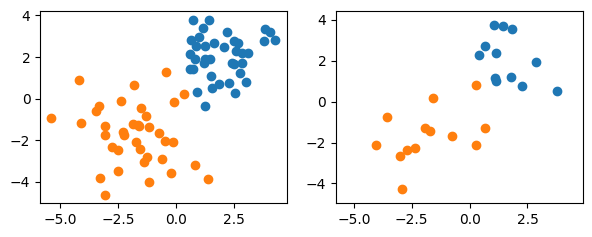

In [3]:
fig, axes = plt.subplots(1,2, figsize=(7, 2.5))

axes[0].scatter(X_train[y_train == 1,0],X_train[y_train == 1,1])
axes[0].scatter(X_train[y_train == 0,0],X_train[y_train == 0,1])

axes[1].scatter(X_test[y_test == 1,0],X_test[y_test == 1,1])
axes[1].scatter(X_test[y_test == 0,0],X_test[y_test == 0,1])

plt.xlim([x[:, 0].min()-0.5, x[:, 0].max()+0.5])
plt.ylim([x[:, 1].min()-0.5, x[:, 1].max()+0.5])
plt.show()


In [4]:
# L2 regularization with weight decay

class LogisticRegression(torch.nn.Module):
  def __init__(self, num_features):
    super(LogisticRegression, self).__init__()

    self.linear = torch.nn.Linear(num_features, 1)
    #self.linear.weight.detach().zero_()
    #self.linear.bias.detach().zero_()
    self.linear.weight.detach().copy_(torch.tensor([1000.0,2.0])) # initialize the weights with 1000 and 2.0

  def forward(self,x):
    logits = self.linear(x)
    probs = torch.sigmoid(logits)

    return probs


In [5]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device).view(-1,1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device=device).view(-1,1)

In [21]:
training_loss_list_without_l2, training_loss_list = [], []

In [22]:
# No cost penality added
L2 = 0
model = LogisticRegression(num_features=2).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(num_epochs):

  out = model(X_train_tensor)

  loss = F.binary_cross_entropy(out, y_train_tensor, reduction='sum')
  training_loss_list.append(loss.item())

  loss = loss

  optimizer.zero_grad()
  loss.backward()

  optimizer.step()

  pred_probs = model(X_train_tensor)
  accuracy = torch.sum(torch.where(pred_probs > 0.5, 1, 0).view(-1) == y_train_tensor.view(-1)).float() / y_train_tensor.size(0)

  print('Epoch: %03d' % (epoch + 1), end="")
  print(' | Train ACC: %.3f' % accuracy, end="")
  print(' | Cost: %.3f' % F.binary_cross_entropy(pred_probs, y_train_tensor))


print('model parameters')
print('weight %s' % model.linear.weight)
print('bias %s' % model.linear.bias)



test_preds = model(X_test_tensor)

test_acc = torch.sum(torch.where(test_preds > 0.5, 1, 0).view(-1) == y_test_tensor.view(-1)).float() / y_test_tensor.size(0)

print(f'test accuracy: {test_acc*100: .2f}')


Epoch: 001 | Train ACC: 0.960 | Cost: 4.000
Epoch: 002 | Train ACC: 0.960 | Cost: 4.000
Epoch: 003 | Train ACC: 0.960 | Cost: 4.000
Epoch: 004 | Train ACC: 0.960 | Cost: 4.000
Epoch: 005 | Train ACC: 0.960 | Cost: 4.000
Epoch: 006 | Train ACC: 0.960 | Cost: 4.000
Epoch: 007 | Train ACC: 0.960 | Cost: 4.000
Epoch: 008 | Train ACC: 0.960 | Cost: 4.000
Epoch: 009 | Train ACC: 0.960 | Cost: 4.000
Epoch: 010 | Train ACC: 0.960 | Cost: 4.000
Epoch: 011 | Train ACC: 0.960 | Cost: 4.000
Epoch: 012 | Train ACC: 0.960 | Cost: 4.000
Epoch: 013 | Train ACC: 0.960 | Cost: 4.000
Epoch: 014 | Train ACC: 0.960 | Cost: 4.000
Epoch: 015 | Train ACC: 0.960 | Cost: 4.000
Epoch: 016 | Train ACC: 0.960 | Cost: 4.000
Epoch: 017 | Train ACC: 0.960 | Cost: 4.000
Epoch: 018 | Train ACC: 0.960 | Cost: 4.000
Epoch: 019 | Train ACC: 0.960 | Cost: 4.000
Epoch: 020 | Train ACC: 0.960 | Cost: 4.000
Epoch: 021 | Train ACC: 0.960 | Cost: 4.000
Epoch: 022 | Train ACC: 0.960 | Cost: 4.000
Epoch: 023 | Train ACC: 0.960 | 

In [23]:
# Penalty added to loss function
L2 = 0
model = LogisticRegression(num_features=2).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(num_epochs):

  out = model(X_train_tensor)

  loss = F.binary_cross_entropy(out, y_train_tensor, reduction='sum')
  # training_loss_list.append(loss.item())
  training_loss_list_without_l2.append(loss.item())

  loss = loss + 0.5 * LAMBDA * torch.mm(model.linear.weight, model.linear.weight.t()) # L2 regularization

  optimizer.zero_grad()
  loss.backward()

  optimizer.step()

  pred_probs = model(X_train_tensor)
  accuracy = torch.sum(torch.where(pred_probs > 0.5, 1, 0).view(-1) == y_train_tensor.view(-1)).float() / y_train_tensor.size(0)

  print('Epoch: %03d' % (epoch + 1), end="")
  print(' | Train ACC: %.3f' % accuracy, end="")
  print(' | Cost: %.3f' % F.binary_cross_entropy(pred_probs, y_train_tensor))


print('model parameters')
print('weight %s' % model.linear.weight)
print('bias %s' % model.linear.bias)



test_preds = model(X_test_tensor)

test_acc = torch.sum(torch.where(test_preds > 0.5, 1, 0).view(-1) == y_test_tensor.view(-1)).float() / y_test_tensor.size(0)

print(f'test accuracy: {test_acc*100: .2f}')


Epoch: 001 | Train ACC: 0.960 | Cost: 4.000
Epoch: 002 | Train ACC: 0.960 | Cost: 4.000
Epoch: 003 | Train ACC: 0.960 | Cost: 4.000
Epoch: 004 | Train ACC: 0.960 | Cost: 4.000
Epoch: 005 | Train ACC: 0.960 | Cost: 4.000
Epoch: 006 | Train ACC: 0.960 | Cost: 4.000
Epoch: 007 | Train ACC: 0.960 | Cost: 4.000
Epoch: 008 | Train ACC: 0.960 | Cost: 4.000
Epoch: 009 | Train ACC: 0.960 | Cost: 4.000
Epoch: 010 | Train ACC: 0.960 | Cost: 4.000
Epoch: 011 | Train ACC: 0.960 | Cost: 4.000
Epoch: 012 | Train ACC: 0.960 | Cost: 4.000
Epoch: 013 | Train ACC: 0.960 | Cost: 4.000
Epoch: 014 | Train ACC: 0.960 | Cost: 2.880
Epoch: 015 | Train ACC: 0.960 | Cost: 2.836
Epoch: 016 | Train ACC: 0.960 | Cost: 2.803
Epoch: 017 | Train ACC: 0.960 | Cost: 2.776
Epoch: 018 | Train ACC: 0.960 | Cost: 1.615
Epoch: 019 | Train ACC: 0.960 | Cost: 1.537
Epoch: 020 | Train ACC: 0.960 | Cost: 0.314
Epoch: 021 | Train ACC: 0.960 | Cost: 0.163
Epoch: 022 | Train ACC: 0.973 | Cost: 0.062
Epoch: 023 | Train ACC: 0.987 | 

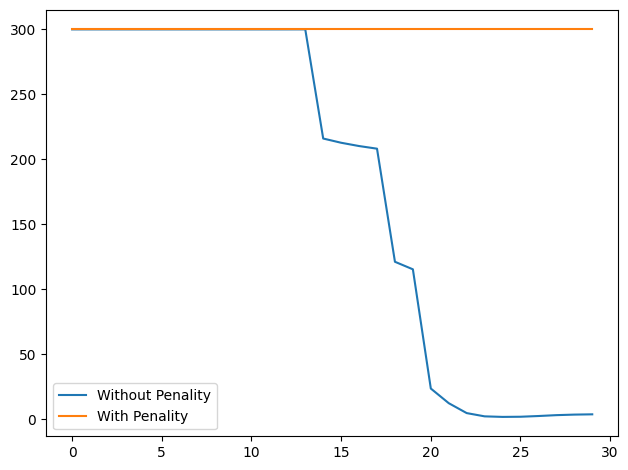

In [24]:
plt.plot(np.arange(30), training_loss_list_without_l2, label = 'Without Penality')
plt.plot(np.arange(30), training_loss_list, label = 'With Penality')

plt.legend()

plt.tight_layout()
plt.show()